In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import timm
import matplotlib.pyplot as plt

BATCH_SIZE = 64
EPOCHS = 5          
LR_PROBE = 1e-3
LR_FINETUNE = 1e-4  
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cuda


In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:02<00:00, 57.4MB/s] 


In [3]:
class CIFAR10ResNet18(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)
        
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.backbone.maxpool = nn.Identity()
        self.embedding_dim = 2048

    def forward(self, x):
        return self.backbone(x)

In [4]:
class LinearProbeModel(nn.Module):
    def __init__(self, backbone, num_classes=10):
        super().__init__()
        self.backbone = backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.classifier = nn.Linear(self.backbone.embedding_dim, num_classes)

    def forward(self, x):
        with torch.no_grad(): 
            features = self.backbone(x)
        return self.classifier(features)

In [5]:
class CNNFineTuneModel(nn.Module):
    def __init__(self, backbone, num_classes=10):
        super().__init__()
        self.backbone = backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.backbone.backbone.layer4.parameters():
            param.requires_grad = True
        self.classifier = nn.Linear(self.backbone.embedding_dim, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

In [6]:
def train_and_evaluate(model, optimizer, criterion, train_loader, test_loader, epochs):
    history = {'train_loss': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)
        
        # Evaluate model performance
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_acc = (correct / total) * 100
        history['test_acc'].append(epoch_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {epoch_loss:.4f} | Test Accuracy: {epoch_acc:.2f}%")
        
    return history

In [7]:
criterion = nn.CrossEntropyLoss()

print("Linear Probe\n")
shared_backbone_probe = CIFAR10ResNet18(pretrained=True).to(DEVICE)
probe_model = LinearProbeModel(shared_backbone_probe).to(DEVICE)

optimizer_probe = optim.AdamW(probe_model.classifier.parameters(), lr=LR_PROBE)
start_time = time.time()
probe_history = train_and_evaluate(probe_model, optimizer_probe, criterion, train_loader, test_loader, EPOCHS)
probe_time = time.time() - start_time

print("Fine-Tuning\n")
shared_backbone_ft = CIFAR10ResNet18(pretrained=True).to(DEVICE)
finetune_model = CNNFineTuneModel(shared_backbone_ft).to(DEVICE)

# Extract only params requiring gradients
ft_params = [p for p in finetune_model.parameters() if p.requires_grad]
optimizer_ft = optim.AdamW(ft_params, lr=LR_FINETUNE)
start_time = time.time()
ft_history = train_and_evaluate(finetune_model, optimizer_ft, criterion, train_loader, test_loader, EPOCHS)
ft_time = time.time() - start_time

Linear Probe



model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Epoch [1/5] -> Train Loss: 1.8420 | Test Accuracy: 41.08%
Epoch [2/5] -> Train Loss: 1.6549 | Test Accuracy: 44.07%
Epoch [3/5] -> Train Loss: 1.6025 | Test Accuracy: 45.44%
Epoch [4/5] -> Train Loss: 1.5668 | Test Accuracy: 46.21%
Epoch [5/5] -> Train Loss: 1.5508 | Test Accuracy: 46.99%
Fine-Tuning



Epoch [1/5] -> Train Loss: 1.9030 | Test Accuracy: 44.31%
Epoch [2/5] -> Train Loss: 1.4783 | Test Accuracy: 51.31%
Epoch [3/5] -> Train Loss: 1.3469 | Test Accuracy: 55.16%
Epoch [4/5] -> Train Loss: 1.2670 | Test Accuracy: 57.37%
Epoch [5/5] -> Train Loss: 1.2074 | Test Accuracy: 59.24%


             BENCHMARK RESULTS            
Protocol             | Final Accuracy (%)   | Runtime (s) 
------------------------------------------------------------
Linear Probe         | 46.99                | 326.0       
Fine-Tune / LoRA     | 59.24                | 452.2       

Training curves successfully saved as 'cnn_benchmark_curves.png'.


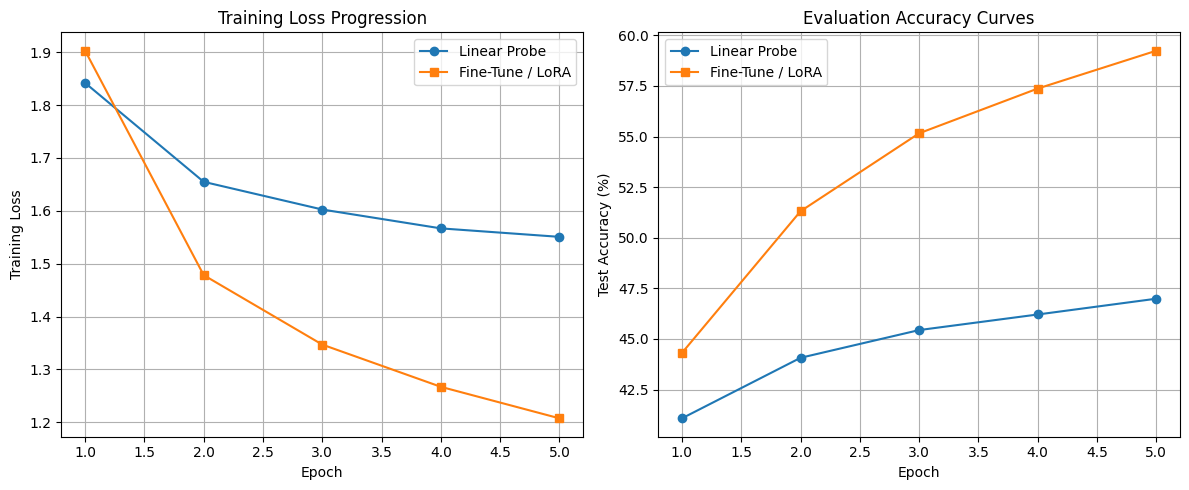

In [8]:
print("             BENCHMARK RESULTS            ")
print(f"{'Protocol':<20} | {'Final Accuracy (%)':<20} | {'Runtime (s)':<12}")
print("-" * 60)
print(f"{'Linear Probe':<20} | {probe_history['test_acc'][-1]:<20.2f} | {probe_time:<12.1f}")
print(f"{'Fine-Tune / LoRA':<20} | {ft_history['test_acc'][-1]:<20.2f} | {ft_time:<12.1f}")
# Generate and save the required training curves
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Plot Losses
plt.subplot(1, 2, 1)
plt.plot(epochs_range, probe_history['train_loss'], label='Linear Probe', marker='o')
plt.plot(epochs_range, ft_history['train_loss'], label='Fine-Tune / LoRA', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Progression')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, probe_history['test_acc'], label='Linear Probe', marker='o')
plt.plot(epochs_range, ft_history['test_acc'], label='Fine-Tune / LoRA', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Evaluation Accuracy Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('cnn_benchmark_curves.png')
print("\nTraining curves successfully saved as 'cnn_benchmark_curves.png'.")